Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.

Ordena el DataFrame por el país de origen. En caso de empate, ordénalo por el nombre de la ciudad.

Muestra las primeras 10 filas.

Adicionalmente, realiza un print que compruebe que el DNI solo tiene valores únicos.

In [1]:
import pandas as pd

# 1. Importar el Excel respetando la estructura real
df = pd.read_excel(
    r"C:\Ana_CDPY\Especializacion\S10.01\sprint10.xlsx",
    sheet_name="Sheet1",
    skiprows=3,     # saltamos las 3 primeras filas de texto
    index_col=0     # usamos la columna A como índice
)

# 2. Comprobar que se importó bien
print(df.head())
print(df.columns)

# 3. Ordenar por país de origen y, en caso de empate, por ciudad
df_ordenado = df.sort_values(
    by=["País d'origen", "Ciutat"]
)

# 4. Mostrar las primeras 10 filas
print(df_ordenado.head(10))

# 5. Comprobar que el DNI tiene valores únicos
print("¿El DNI tiene valores únicos?:", df_ordenado["DNI"].is_unique)

df_ordenado.head(10)

       Nom           Cognoms        DNI País d'origen     Ciutat  \
0     Inês    Ferreira Silva  16928694K      Portugal     Lisboa   
1    Clara  Sánchez Martínez  27724652S       Espanya  Barcelona   
2   Fatima             Fassi  38141675A        Marroc      Rabat   
3  Khadija   Bennani Bennani  59157262R        Marroc      Rabat   
4     Toni    Sánchez García  69630528M       Espanya  Barcelona   

   Dia de Naixement  Mes de Naixement  Any de Naixement Gènere Salari mensual  \
0                25                 2              1953      D        1.144 €   
1                18                 3              1996      D        1.253 €   
2                 6                11              2005      A        1.441 €   
3                20                 1              1995      D        1.944 €   
4                 9                 8              1999      H        1.043 €   

   Fills  No Fills Grup Professional  
0    NaN       1.0            Grup B  
1    1.0       NaN        

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


2.
Crea una columna que contenga el nombre completo.
Crea una columna que indique si la persona ha nacido en España o no.
Establece el DNI como índice del DataFrame (nombres de filas).

Sustituye los nombres de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

Sustituye:

H por Hombre

D por Mujer

A por Otros

NC por un valor faltante (NaN / null)

Muestra todos los cambios realizados en una sola tabla.

In [2]:
import pandas as pd
import numpy as np

# 1. Cargar el archivo respetando la estructura del Excel
df = pd.read_excel(
    r"C:\Ana_CDPY\Especializacion\S10.01\sprint10.xlsx",
    sheet_name="Sheet1",
    skiprows=3,
    index_col=0
)

# 2. Crear columna con el nombre completo
df["Nombre completo"] = df["Nom"] + " " + df["Cognoms"]

# 3. Crear columna si la persona ha nacido en España
df["Nacido en España"] = df["País d'origen"] == "Espanya"

# 4. Poner el DNI como índice
df.set_index("DNI", inplace=True)

# 5. Renombrar columnas de fecha de nacimiento
df.rename(
    columns={
        "Dia de Naixement": "Dia",
        "Mes de Naixement": "Mes",
        "Any de Naixement": "Any"
    },
    inplace=True
)

# 6. Sustituir valores de la columna Género
df["Gènere"] = df["Gènere"].replace({
    "H": "Hombre",
    "D": "Mujer",
    "A": "Otros",
    "NC": np.nan
})

# 7. Mostrar el resultado final con todos los cambios
df.head(10)


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nombre completo,Nacido en España
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Mujer,1.144 €,NaN,1.0,Grup B,Inês Ferreira Silva,False
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Mujer,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,True
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Otros,1.441 €,1.0,NaN,Grup A,Fatima Fassi,False
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Mujer,1.944 €,NaN,1.0,Grup B,Khadija Bennani Bennani,False
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Hombre,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,True
26930927E,Laia,Castells Ferrer,Espanya,Madrid,16,12,1953,Otros,2.611 €,NaN,1.0,Grup D,Laia Castells Ferrer,True
78247593G,Carla,García,Espanya,València,24,12,1957,Mujer,942 €,NaN,1.0,Grup A,Carla García,True
21774231J,Marco,Rossi,Itàlia,Torí,3,11,2002,Otros,1.494 €,NaN,1.0,Grup A,Marco Rossi,False
87316866D,Alessia,Rossi,Itàlia,Milà,6,12,1989,Mujer,1.366 €,NaN,1.0,Grup A,Alessia Rossi,False


Une las columnas Fills y No Fills en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema.

La nueva columna debe llamarse "Fills" y tomar únicamente los valores "Sí" o "No".

In [3]:
def tiene_hijos(fila):
    if fila["Fills"] == 1.0:
        return "Sí"
    elif fila["No Fills"] == 1.0:
        return "No"
    else:
        return None

df["Fills"] = df.apply(tiene_hijos, axis=1)

df.head(10)


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nombre completo,Nacido en España
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Mujer,1.144 €,No,1.0,Grup B,Inês Ferreira Silva,False
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Mujer,1.253 €,Sí,NaN,Grup A,Clara Sánchez Martínez,True
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Otros,1.441 €,Sí,NaN,Grup A,Fatima Fassi,False
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Mujer,1.944 €,No,1.0,Grup B,Khadija Bennani Bennani,False
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Hombre,1.043 €,No,1.0,Grup A,Toni Sánchez García,True
26930927E,Laia,Castells Ferrer,Espanya,Madrid,16,12,1953,Otros,2.611 €,No,1.0,Grup D,Laia Castells Ferrer,True
78247593G,Carla,García,Espanya,València,24,12,1957,Mujer,942 €,No,1.0,Grup A,Carla García,True
21774231J,Marco,Rossi,Itàlia,Torí,3,11,2002,Otros,1.494 €,No,1.0,Grup A,Marco Rossi,False
87316866D,Alessia,Rossi,Itàlia,Milà,6,12,1989,Mujer,1.366 €,No,1.0,Grup A,Alessia Rossi,False


4
Crea una tabla resumen que permita ver el salario medio, mediano, mínimo y máximo por Género.

Ordena la tabla en función del salario medio.

In [4]:
# Limpiar la columna de salario y convertirla a numérica
df["Salari mensual"] = (
    df["Salari mensual"]
    .str.replace("€", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)


In [5]:
tabla_resumen = (
    df.groupby("Gènere")["Salari mensual"]
      .agg(
          Sou_mig="mean",
          Sou_medià="median",
          Sou_mínim="min",
          Sou_màxim="max"
      )
      .sort_values(by="Sou_mig", ascending=False)
)
tabla_resumen


,Sou_mig,Sou_medià,Sou_mínim,Sou_màxim
Gènere,,,,
Hombre,1643.249443,1531.0,737.0,3356.0
Otros,1626.588235,1545.0,703.0,3175.0
Mujer,1469.443182,1361.5,665.0,3021.0


5.
Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

Añade las medias en los márgenes de la tabla.

(EXTRA): Aplica formato condicional a la tabla para visualizar con un color más intenso los valores más elevados.

In [6]:
tabla_resumen = pd.pivot_table(
    df,
    values="Salari mensual",
    index="Gènere",            # Filas
    columns="País d'origen",   # Columnas
    aggfunc="mean",
    margins=True,              # Añade medias en márgenes
    margins_name="Media"
)
tabla_resumen 
tabla_resumen.style.format("{:.2f}").background_gradient(cmap="Blues")



País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Media,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


6.
Crea una nueva columna que contenga la fecha de nacimiento en formato Datetime, a partir de las columnas día, mes y año.

Utilizando esta columna, crea una función que, dada una fecha, calcule la edad actual a día de hoy.

Usa la función que acabas de crear para generar una nueva columna en el DataFrame con la edad actual.

In [7]:
import pandas as pd
from datetime import date

# Crear la columna Fecha de Nacimiento en formato datetime
df["Fecha_nacimiento"] = pd.to_datetime(
    df[["Any", "Mes", "Dia"]].rename(
        columns={"Any": "year", "Mes": "month", "Dia": "day"}
    )
)


In [8]:
from datetime import date

def calcular_edad(fecha_nacimiento):
    hoy = date.today()
    edad = hoy.year - fecha_nacimiento.year

    # Si aún no ha cumplido años este año, restamos 1
    if (hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day):
        edad -= 1

    return edad
df["Edad_actual"] = df["Fecha_nacimiento"].apply(calcular_edad)

df[["Fecha_nacimiento", "Edad_actual"]].head(10)

,Fecha_nacimiento,Edad_actual
DNI,,
16928694K,1953-02-25,73
27724652S,1996-03-18,29
38141675A,2005-11-06,20
59157262R,1995-01-20,31
69630528M,1999-08-09,26
26930927E,1953-12-16,72
78247593G,1957-12-24,68
21774231J,2002-11-03,23
87316866D,1989-12-06,36


NIVEL 2
Utilizando el siguiente DataFrame, añade la columna “Increment” al DataFrame del nivel anterior.

    df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , 
    "Increment":["5%","3,5%","2%","8%"]})
    


In [9]:
import pandas as pd

df_increment = pd.DataFrame({
    "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})


In [10]:
#Convertir el porcentaje a número 
df_increment["Increment"] = (
    df_increment["Increment"]
    .str.replace("%", "")
    .str.replace(",", ".")
    .astype(float) / 100
)


In [11]:
#Unir los incrementos al DataFrame principal
df = df.merge(
    df_increment,
    left_on="Grup Professional",
    right_on="Grup",
    how="left"
)


In [12]:
#Actualizar salario con el incremento

df["Salari mensual"] = df["Salari mensual"] * (1 + df["Increment"])


In [13]:
#Eliminar columna auxiliar
df.drop(columns=["Grup"], inplace=True)
df.head()


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nombre completo,Nacido en España,Fecha_nacimiento,Edad_actual,Increment
0,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Mujer,1184.04,No,1.0,Grup B,Inês Ferreira Silva,False,1953-02-25,73,0.035
1,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Mujer,1315.65,Sí,NaN,Grup A,Clara Sánchez Martínez,True,1996-03-18,29,0.050
2,Fatima,Fassi,Marroc,Rabat,6,11,2005,Otros,1513.05,Sí,NaN,Grup A,Fatima Fassi,False,2005-11-06,20,0.050
3,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Mujer,2012.04,No,1.0,Grup B,Khadija Bennani Bennani,False,1995-01-20,31,0.035
4,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Hombre,1095.15,No,1.0,Grup A,Toni Sánchez García,True,1999-08-09,26,0.050


2.
Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...
Actualiza la columna salario en función de los porcentajes que se adjuntan.
No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

In [14]:
# Exportar.csv
grupos = df["Grup Professional"].unique()

for grupo in grupos:
    df_grupo = df[df["Grup Professional"] == grupo]
    nombre_archivo = f"dades_{grupo.replace(' ', '')}.csv"
    df_grupo.to_csv(nombre_archivo, index=False)


In [15]:
#creo dataframe resumen para luego exportar en .csv
df_resumen = (
    df.groupby("Grup Professional")
      .agg(
          Trabajadores=("Grup Professional", "count"),
          Salario_medio=("Salari mensual", "mean"),
          Edad_mediana=("Edad_actual", "median")
      )
      .reset_index()
)
df_resumen.to_csv("resumen_grupo_profesional.csv", index=False)
df_resumen

,Grup Professional,Trabajadores,Salario_medio,Edad_mediana
0,Grup A,490,1213.324286,51.0
1,Grup B,318,1724.550849,47.0
2,Grup C,137,2289.192701,51.0
3,Grup D,55,3100.817455,43.0


NIVEL III
Crea una función que reciba un DataFrame como parámetro de entrada.
La función debe crear y exportar automáticamente un gráfico para cada columna del DataFrame. Por ejemplo:

    --Un histograma (o boxplot) si la variable es numérica

    --Un gráfico de barras con los valores más frecuentes si la variable es categórica

    --Un gráfico de barras por año si la variable es de tipo fecha

La idea es que la función funcione para cualquier DataFrame, no solo para el que hemos usado hasta ahora.
Muestra el resultado de la función usando alguno de los datasets de ejemplo de seaborn, como iris, penguins o titanic.
El objetivo no es hacer gráficos elaborados, sino resolver el problema de forma rápida y automática.

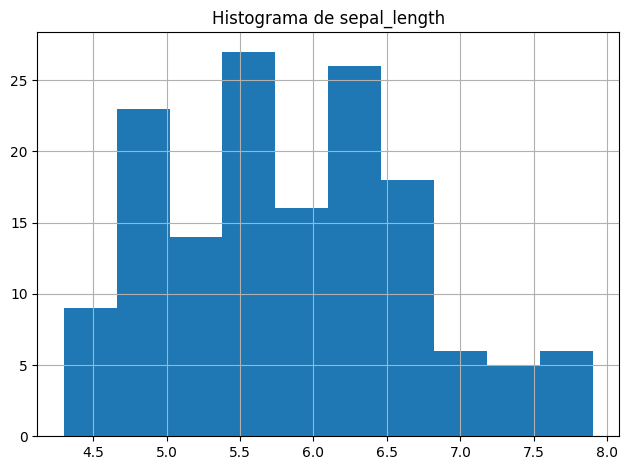

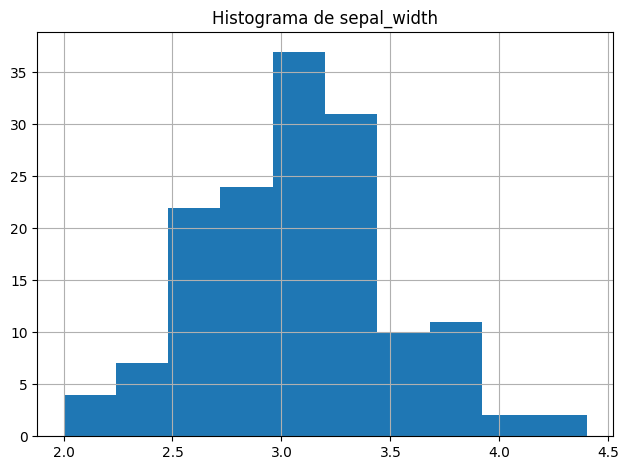

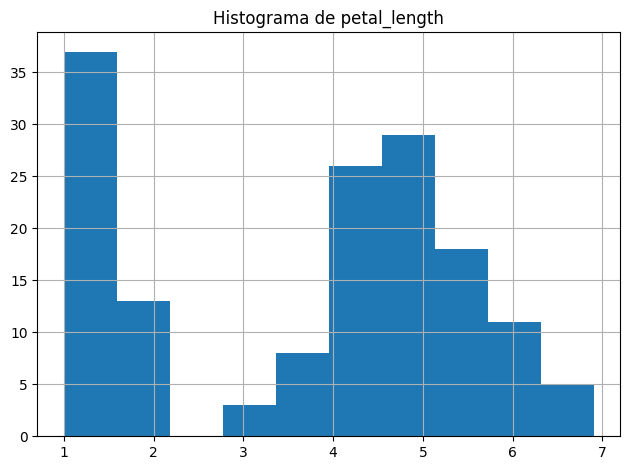

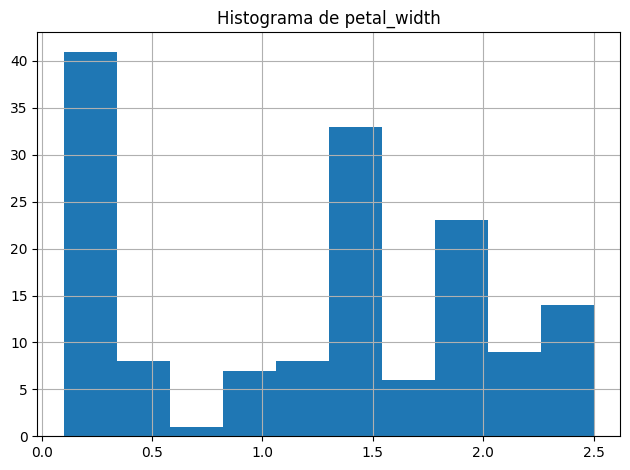

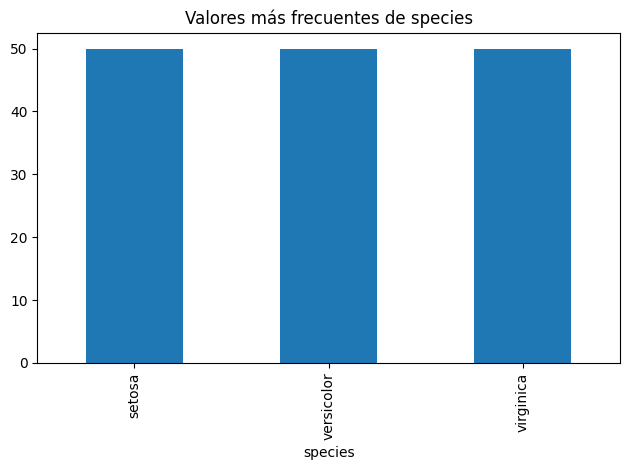

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def graficos_automaticos(df):
    for columna in df.columns:
        
        plt.figure()
        
        # Variables numéricas
        if pd.api.types.is_numeric_dtype(df[columna]):
            df[columna].dropna().hist()
            plt.title(f"Histograma de {columna}")
        
        # Variables de fecha
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):
            df[columna].dt.year.value_counts().sort_index().plot(kind="bar")
            plt.title(f"Años más frecuentes en {columna}")
        
        # Variables categóricas
        else:
            df[columna].value_counts().head(10).plot(kind="bar")
            plt.title(f"Valores más frecuentes de {columna}")
        
        # Guardar gráfico
        plt.tight_layout()
        plt.savefig(f"grafico_{columna}.png")
        plt.show()
        
df_ejemplo = sns.load_dataset("iris")

graficos_automaticos(df_ejemplo)


Carga el archivo matriu_distancies.xlsx en Pandas, de manera que los nombres de las filas y de las columnas sean los de las ciudades.

Elimina “Las Palmas de Gran Canaria” y “Palma”, ya que el trayecto se realizará en coche.

Fuente: Mejores Rutas.

Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

    No es necesario hacerlo de forma óptima; interesa desarrollar una solución razonable usando las herramientas actuales.

Por ejemplo, una aproximación sencilla (no óptima) sería ir siempre a la ciudad más cercana que no se haya visitado aún.

Crea una función que, dada la matriz de distancias y una ciudad de origen, proponga una ruta lo más corta posible, devolviendo:

    --  una lista con el orden de visita

    -- la distancia total recorrida

(EXTRA) ¿Desde qué ciudad la ruta sería más corta con el algoritmo planteado?

In [17]:
# Cargar archivo y preparar la matriz
import pandas as pd

# Cargar la matriz de distancias
df_dist = pd.read_excel(r"C:\Ana_CDPY\Especializacion\S10.01\matriu_distancies.xlsx", index_col=0)

# Eliminar ciudades no accesibles en coche
df_dist = df_dist.drop(
    index=["Las Palmas de Gran Canaria", "Palma"],
    columns=["Las Palmas de Gran Canaria", "Palma"]
)


In [ ]:
#Función para calcular una ruta (algoritmo voraz)
def ruta_mas_corta(matriz, ciudad_origen):
    ciudades_pendientes = set(matriz.index)
    ciudad_actual = ciudad_origen
    ruta = [ciudad_actual]
    distancia_total = 0

    ciudades_pendientes.remove(ciudad_actual) # modifica la matriz cada vez que avanza a una ciudad

    while ciudades_pendientes:
        # Distancias desde la ciudad actual a las no visitadas.
        # “Obtiene de la matriz la fila correspondiente a la ciudad actual,
        #  pero solo en las columnas que corresponden a las ciudades pendientes.”
        
        distancias = matriz.loc[ciudad_actual, list(ciudades_pendientes)]
        # y luego,
        # Elige la ciudad más cercana
        siguiente_ciudad = distancias.idxmin() # escencia de algoritmo voraz
        distancia_total += distancias.min()
        
        ruta.append(siguiente_ciudad) # se extendiende la sucesión
        ciudad_actual = siguiente_ciudad
        ciudades_pendientes.remove(siguiente_ciudad)

    return ruta, distancia_total # aunque no ponga parentesis me devuelve una tupla (ruta, distancia_total)


In [19]:
#Probar la función
ruta, distancia = ruta_mas_corta(df_dist, "Barcelona") # Desempaquetamiento de Tupla

print("Ruta propuesta:")
print(ruta)

print("\nDistancia total recorrida:", distancia, "km")


Ruta propuesta:
['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Murcia', 'Alicante', 'Valencia']

Distancia total recorrida: 2646.0 km


In [20]:
""" import pandas as pd

datos_ruta = []

for i in range(len(ruta) - 1):
    origen = ruta[i]
    destino = ruta[i + 1]
    distancia_tramo = df_dist.loc[origen, destino]

    datos_ruta.append({
        "Origen": origen,
        "Destino": destino,
        "Distancia (km)": distancia_tramo
    })

df_ruta = pd.DataFrame(datos_ruta)
df_ruta
"""

' import pandas as pd\n\ndatos_ruta = []\n\nfor i in range(len(ruta) - 1):\n    origen = ruta[i]\n    destino = ruta[i + 1]\n    distancia_tramo = df_dist.loc[origen, destino]\n\n    datos_ruta.append({\n        "Origen": origen,\n        "Destino": destino,\n        "Distancia (km)": distancia_tramo\n    })\n\ndf_ruta = pd.DataFrame(datos_ruta)\ndf_ruta\n'

In [21]:
#EXTRA
mejor_ciudad = None # es none porque alamcenara un str( nombre de ciudad)
mejor_distancia = float("inf") # float("inf") significa infinito, técnica para buscar minimos
                               # queremos comparar distancias y quedarnos con la menor.
                              #Si empezamos con infinito, cualquier distancia real será menor.

mejor_ruta = None  # es none porque es una lista de str

for ciudad in df_dist.index:
    ruta, distancia = ruta_mas_corta(df_dist, ciudad) #desempaquetamiento de tupla

    if distancia < mejor_distancia:
        mejor_distancia = distancia
        mejor_ciudad = ciudad
        mejor_ruta = ruta

print("La ciudad desde la que la ruta es más corta es:", mejor_ciudad)
print("Distancia total:", mejor_distancia, "km")


La ciudad desde la que la ruta es más corta es: Barcelona
Distancia total: 2646.0 km
